# Merge and Export Machine Learning Dataset (regression) — Milan
This notebook gathers all pre-calculated features (OSM POIs, Land Use, Momepy) and merges them with the **real noise values in dB** into one comprehensive `.csv` table for testing the Barcelona regression models, mirroring `notebooks/_elena/01_create_dataset_regre.ipynb`.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datasets

In [2]:
path_osm_roads    = "data/osm_roads_noise_regre.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points   = "data/osm_points_features.csv"
path_osmlanduse   = "data/osm_landuse_features.csv"

df_osm_roads    = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points   = pd.read_csv(path_osm_points)
df_osm_landuse  = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,10371529_743371634_0,65.0,65.0,55.0,2,1139.168597,0.000000,3243.971228,0.000000,295.923522,288.328932
1,10371529_743371622_0,65.0,65.0,55.0,4,1106.773564,0.000000,3243.971228,0.000000,289.266957,266.547014
2,10371530_267873043_0,65.0,65.0,55.0,2,2119.581742,0.000000,1317.601503,79.177942,14.866980,1472.511721
3,13595397_271096577_0,65.0,65.0,55.0,3,0.000000,436.049701,0.000000,194.533835,13.506098,2720.309808
4,13595397_344814479_0,65.0,65.0,55.0,3,10.182633,436.049701,0.000000,194.533835,0.000000,2717.720476


In [4]:
df_momepy_roads.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,10371529_743371634_0,50.000000,1.000000,0.000164,0.000096,6.969207e-06,0.839291
1,10371529_743371622_0,50.000000,1.000000,0.006359,0.000096,6.561615e-06,0.839074
2,10371530_267873043_0,38.839167,0.915254,0.000328,0.000102,7.732951e-07,0.736890
3,13595397_271096577_0,50.000000,1.000000,0.004028,0.000139,2.246224e-05,0.814577
4,13595397_344814479_0,50.000000,1.000000,0.000223,0.000139,2.194961e-05,0.813434


In [5]:
# Drop non-ML columns from momepy (openness is a morphological intermediate)
df_momepy_roads.drop(['openness'], axis=1, inplace=True)
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness_400,straightness
0,10371529_743371634_0,50.000000,0.000164,0.000096,6.969207e-06,0.839291
1,10371529_743371622_0,50.000000,0.006359,0.000096,6.561615e-06,0.839074
2,10371530_267873043_0,38.839167,0.000328,0.000102,7.732951e-07,0.736890
3,13595397_271096577_0,50.000000,0.004028,0.000139,2.246224e-05,0.814577
4,13595397_344814479_0,50.000000,0.000223,0.000139,2.194961e-05,0.813434


In [6]:
df_osm_points.head()

,road_id,signals,transport,pois
0,10371529_743371634_0,0.025901,0.000000,0.000000
1,10371529_743371622_0,0.006646,0.000000,0.000000
2,10371530_267873043_0,0.001859,0.000930,0.001859
3,13595397_271096577_0,0.139212,0.047702,0.000000
4,13595397_344814479_0,0.139212,0.000000,0.000000


In [7]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,10371529_743371634_0,100.000000,0.0,0.0
1,10371529_743371622_0,100.000000,0.0,0.0
2,10371530_267873043_0,93.899704,0.0,0.0
3,13595397_271096577_0,3.926710,0.0,0.0
4,13595397_344814479_0,4.536889,0.0,0.0


## Merge dataframes

In [8]:
def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    return base_df.merge(clean_df, on='road_id', how='left')

In [9]:
ml_dataset = df_osm_roads.copy()
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points',   df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse',  df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,10371529_743371634_0,65.0,65.0,55.0,2,1139.168597,0.000000,3243.971228,0.000000,295.923522,...,0.000000,0.000000,50.000000,0.000164,0.000096,6.969207e-06,0.839291,100.000000,0.0,0.0
1,10371529_743371622_0,65.0,65.0,55.0,4,1106.773564,0.000000,3243.971228,0.000000,289.266957,...,0.000000,0.000000,50.000000,0.006359,0.000096,6.561615e-06,0.839074,100.000000,0.0,0.0
2,10371530_267873043_0,65.0,65.0,55.0,2,2119.581742,0.000000,1317.601503,79.177942,14.866980,...,0.000930,0.001859,38.839167,0.000328,0.000102,7.732951e-07,0.736890,93.899704,0.0,0.0
3,13595397_271096577_0,65.0,65.0,55.0,3,0.000000,436.049701,0.000000,194.533835,13.506098,...,0.047702,0.000000,50.000000,0.004028,0.000139,2.246224e-05,0.814577,3.926710,0.0,0.0
4,13595397_344814479_0,65.0,65.0,55.0,3,10.182633,436.049701,0.000000,194.533835,0.000000,...,0.000000,0.000000,50.000000,0.000223,0.000139,2.194961e-05,0.813434,4.536889,0.0,0.0
5,13595397_8383189623_0,65.0,65.0,55.0,3,10.182633,416.187764,0.000000,183.771870,13.506098,...,0.000000,0.000000,40.381448,0.002291,0.000140,1.537392e-05,0.810147,1.796143,0.0,0.0
6,13598756_245474388_0,65.0,65.0,55.0,4,1242.906342,980.257953,0.000000,0.000000,0.000000,...,0.056173,0.056173,50.000000,0.002788,0.000194,1.586682e-05,0.828882,19.368899,0.0,0.0
7,13598756_243908533_0,65.0,65.0,55.0,5,1111.677328,947.570560,35.630496,0.000000,0.000000,...,0.007625,0.015250,32.306448,0.002637,0.000193,1.501392e-05,0.825552,20.298136,0.0,0.0
8,13598788_13919627_0,65.0,65.0,55.0,5,508.710448,499.614184,0.000000,102.398632,0.000000,...,0.089720,0.018184,34.909607,0.000259,0.000184,1.855746e-05,0.834188,9.003846,0.0,0.0
9,13598788_12452780553_0,65.0,65.0,55.0,5,464.736103,455.692330,0.000000,54.423978,0.000000,...,0.075755,0.000000,50.000000,0.000064,0.000184,1.926442e-05,0.835898,9.275098,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 22164 entries, 0 to 22163
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                22164 non-null  str    
 1   noise_day              22164 non-null  float64
 2   noise_evening          22164 non-null  float64
 3   noise_night            22164 non-null  float64
 4   road_category          22164 non-null  int64  
 5   dist_to_trunk          22164 non-null  float64
 6   dist_to_primary        22164 non-null  float64
 7   dist_to_secondary      22164 non-null  float64
 8   dist_to_tertiary       22164 non-null  float64
 9   dist_to_residential    22164 non-null  float64
 10  dist_to_living_street  22164 non-null  float64
 11  signals                22164 non-null  float64
 12  transport              22164 non-null  float64
 13  pois                   22164 non-null  float64
 14  width                  22164 non-null  float64
 15  betweenness  

## Noise distribution

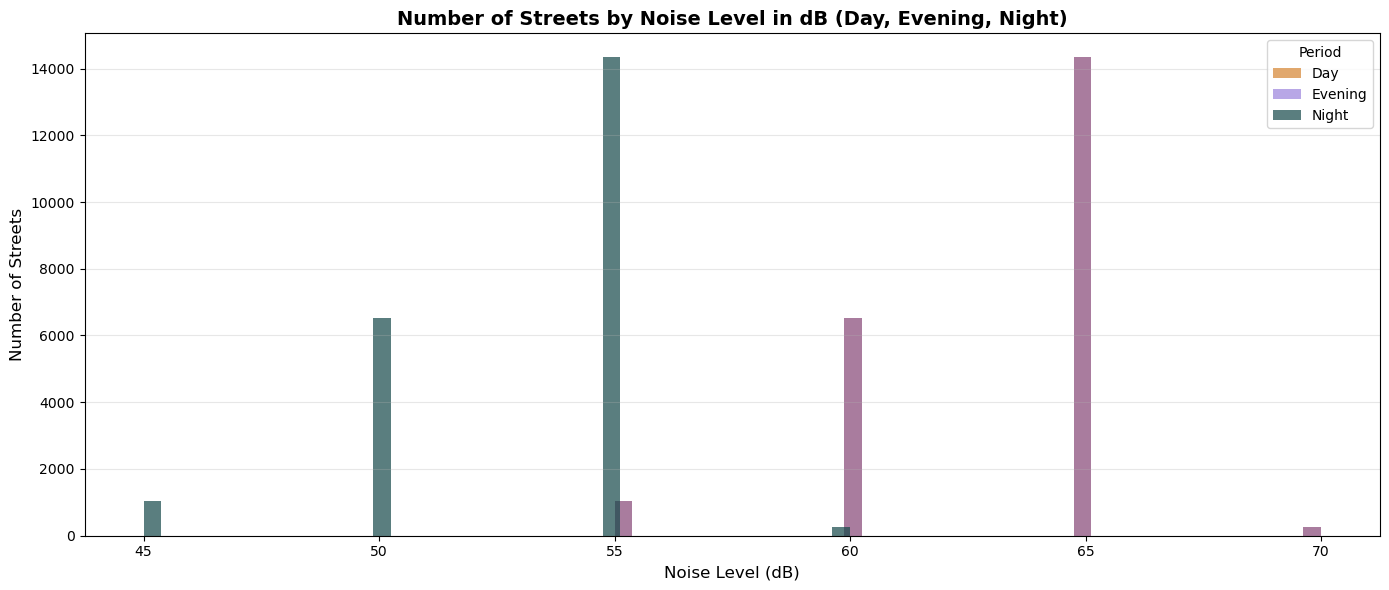

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(ml_dataset['noise_day'], bins=40, color='#d58430', alpha=0.7, label='Day')
ax.hist(ml_dataset['noise_evening'], bins=40, color='#7251ce', alpha=0.5, label='Evening')
ax.hist(ml_dataset['noise_night'], bins=40, color='#144849', alpha=0.7, label='Night')
ax.set_title('Number of Streets by Noise Level in dB (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.tight_layout()
plt.show()

## Export to CSV
Final master table for testing the Barcelona regression models.

In [11]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "mil_noise_regre_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\mil_noise_regre_ml_dataset.csv


## Subsample
Stratified subsample preserving the noise_day distribution. The dB values can be continuous, so the stratification uses 5-dB bins (Barcelona's exact-value stratification would put every street in its own stratum).

In [12]:
sample_size = min(5000, len(ml_dataset))

bins = (ml_dataset['noise_day'] // 5 * 5).astype(int)
proportions = bins.value_counts(normalize=True).sort_index()
samples_per_value = (proportions * sample_size).round().astype(int)

subsampled = pd.concat([
    ml_dataset[bins == val].sample(n=min(n, int((bins == val).sum())), random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print((subsampled['noise_day'] // 5 * 5).astype(int).value_counts(normalize=True).sort_index())

noise_day
55    0.0474
60    0.2938
65    0.6470
70    0.0118
Name: proportion, dtype: float64


## Before and after sampling

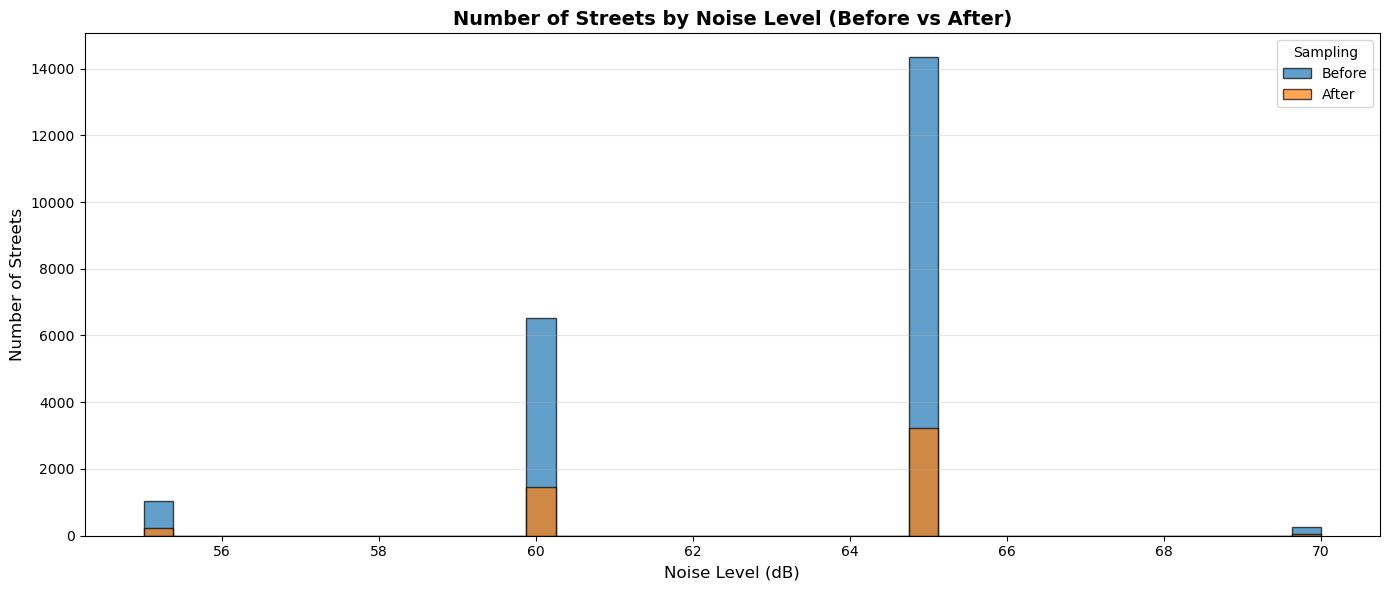

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.hist(ml_dataset['noise_day'], bins=40, alpha=0.7, label='Before', edgecolor='black')
ax.hist(subsampled['noise_day'], bins=40, alpha=0.7, label='After', edgecolor='black')
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Sampling')
plt.tight_layout()
plt.show()

## Export CSV

In [14]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "mil_noise_regre_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\mil_noise_regre_ml_subsample.csv


## Schema check vs Barcelona
The columns must match `bcn_noise_regre_ml_dataset.csv` exactly (names and order) so the pickled scaler/models apply directly.

In [15]:
bcn = pd.read_csv("../../../notebooks/_elena/data/bcn_noise_regre_ml_dataset.csv", nrows=5)

print("Columns match Barcelona schema:", list(ml_dataset.columns) == list(bcn.columns))
print("NaN values:", ml_dataset.isna().sum().sum())
print("Duplicated road_id:", ml_dataset['road_id'].duplicated().sum())
assert list(ml_dataset.columns) == list(bcn.columns), "schema mismatch with Barcelona"
print("Schema parity with Barcelona confirmed.")

Columns match Barcelona schema: True
NaN values: 0
Duplicated road_id: 0
Schema parity with Barcelona confirmed.
